# Agent-based Simulation with MESA
Mesa allows users to quickly create agent-based models using built-in core components (such as spatial grids and agent schedulers) or customized implementations; visualize them using a browser-based interface; and analyze their results using Python’s data analysis tools.

## Set up
**!!Make sure using the env launching Jupyter lab matching the kernel env!!**

[Installation guide](https://mesa.readthedocs.io/latest/index.html) on Mesa's official website.  
Use Conda(https://anaconda.org/conda-forge/mesa) to install for manageability in controlled environment.  
Install [Solara](https://solara.dev/) for interactive visulization(`ipyvuetify`&`ipyvue` needed).
- Run `python -V` in terminal to check Python version.  
- Run `conda install - c conda-forge mesa solara altair` to install packages.  
- Check their versions by running `conda list solara` & `conda list mesa`.
- Check Jupyter extensions: `jupyter labextension list`
- Remember to restart the kernel.

### Import Dependencies

In [22]:
import numpy as np
import pandas as pd
import seaborn as sns
import mesa
# Import Cell Agent and OrthogonalMooreGrid
from mesa.discrete_space import CellAgent, OrthogonalMooreGrid
from mesa.visualization import SolaraViz, make_plot_component, make_space_component
import solara
from matplotlib.figure import Figure
# due to the way Solara works we need to trigger an update whenever the underlying model changes. 
# For this you need to register an update counter with every component.
from mesa.visualization.utils import update_counter

In [2]:
import solara
solara.check_jupyter()

In [3]:
import sys
print(sys.executable)

/opt/miniconda3/envs/my_env/bin/python


## Create Agent
Follow the [tutorial](https://mesa.readthedocs.io/latest/tutorials/0_first_model.html) from Mesa document.  
This particular case simulate an economy with agents as consumer or producer exanging money. [[Drăgulescu, 2002](https://arxiv.org/abs/cond-mat/0211175)]. 

An agent has a initial state and actions defined with functions.  
`exchange`: the agent will check its wealth, and if it has money, give one unit of it away to another random agent.

In [2]:
# Instantiate MoneyAgent as CellAgent
# class MoneyAgent(mesa.Agent):
class MoneyAgent(CellAgent):
    """An agent with fixed initial wealth."""

    def __init__(self, model, cell, ethnicity):
        super().__init__(model)
        self.cell = cell  # Instantiate agent with location (x,y)
        self.wealth = 1
        self.ethnicity = ethnicity
        
    def say_hi(self):
        # The agent's step will go here.
        # For demonstration purposes we will print the agent's unique_id
        print(f"Hi, I am an agent, you can call me {self.unique_id!s}.")
        
    def say_wealth(self):
        print(f"my wealth is {self.wealth}")

    # Move Function
    def move(self):
        self.cell = self.cell.neighborhood.select_random_cell()

    def exchange(self):
        # Verify agent has some wealth
        if self.wealth > 0:
            other_agent = self.random.choice(self.model.agents)
            if other_agent is not None:
                other_agent.wealth += 1
                self.wealth -= 1
    
    # The new function only gives money to poor agents
    def give_money_a(self, poor_agents):
        if self.wealth > 0:
            other_agent = self.random.choice(poor_agents)
            other_agent.wealth += 1
            self.wealth -= 1            
    # exchange money based on ethnicity        
    def give_money_b(self, similars):
        if self.wealth > 0:
            other_agent = self.random.choice(similars)
            other_agent.wealth += 1
            self.wealth -= 1
    
    """ ---------------- Obsolete ----------------
    def give_money(self):
        cellmates = [
            a for a in self.cell.agents if a is not self
        ]  # Get all agents in cell

        if self.wealth > 0 and cellmates:
            other_agent = self.random.choice(cellmates)
            other_agent.wealth += 1
            self.wealth -= 1
    """

## Create Model
A model is a set of agents.  
Use `step` function to tell agent what to do in one smallest unit of time(tick/step) in the model.

In [39]:
class MoneyModel(mesa.Model):
    """A model with some number of agents."""

    def __init__(self, n=50, width=10, height=10, seed=None):
        """Initialize a MoneyModel instance.

        Args:
            n: The number of agents.
            width: width of the grid.
            height: Height of the grid.
        """
        super().__init__(seed=seed)
        self.num_agents = n
        
        # Instantiate an instance of Moore neighborhood space
        self.grid = OrthogonalMooreGrid(
            (width, height), torus=True, random=self.random
        )

        # Create a list of our different ethnicities
        ethnicities = ["Green", "Blue", "Mixed"]

        # Create agents
        # MoneyAgent.create_agents(model=self, n=n)
        MoneyAgent.create_agents(
            self,
            self.num_agents,
            # Randomly select agents cell
            self.random.choices(self.grid.all_cells.cells, k=self.num_agents),
            ethnicity=self.random.choices(ethnicities, k=self.num_agents),
        )

        # Instantiate DataCollector
        self.datacollector = mesa.DataCollector(
            model_reporters={"Gini": compute_gini}, 
            agent_reporters={"Wealth": "wealth", "Ethnicity": "ethnicity"},
        )

    def step(self):
        """Advance the model by one step."""
        # This function psuedo-randomly reorders the list of agent objects and
        # then iterates through calling the function passed in as the parameter   
        
        # Collect data each step
        self.datacollector.collect(self)
        
        self.agents.shuffle_do("move")
        
        # Get lists of rich and poor agents
        rich_agents = self.agents.select(lambda a: a.wealth >= 3)
        poor_agents = self.agents.select(lambda a: a.wealth < 3)
        # When there is rich agents only have them give money to poor agents
        if len(rich_agents) > 0:
            rich_agents.shuffle_do("give_money_a", poor_agents)
        else:
            poor_agents.shuffle_do("give_money_a", poor_agents)

        """ ---------------- Obsolete ----------------  
        # Create dictionary of agents groupby
        grouped_agents = model.agents.groupby("ethnicity")
        for ethnic, similars in grouped_agents:
            if ethnic != "Mixed":
                similars.shuffle_do("give_money_b", similars)
            else:
                similars.shuffle_do(
                    "give_money_b", self.agents
                )  # This allows mixed to trade with anyone
             
        self.agents.shuffle_do("exchange")     
        self.agents.shuffle_do("say_hi")
        self.agents.do("give_money")
        """

## Running the Model

Instantiate our pre-defined model and call the step method(in each step, randomly choose one agent and call `say_hi` function) one time.

In [20]:
starter_model = MoneyModel(10, seed=42)
starter_model.step()

Hi, I am an agent, you can call me 8.
Hi, I am an agent, you can call me 4.
Hi, I am an agent, you can call me 3.
Hi, I am an agent, you can call me 9.
Hi, I am an agent, you can call me 6.
Hi, I am an agent, you can call me 7.
Hi, I am an agent, you can call me 10.
Hi, I am an agent, you can call me 5.
Hi, I am an agent, you can call me 1.
Hi, I am an agent, you can call me 2.


### Create a model with 100 agents on a 10x10 grid, and run it for 20 steps.

In [52]:
model = MoneyModel(100, 10, 10)
for _ in range(20):
    model.step()

Create 10 agents and run 30 steps, each steps randomly choose one agent to call `exchange` function.

In [24]:
model = MoneyModel(10, seed=42)  # Tells the model to create 10 agents
for _ in range(30):  # Runs the model for 30 steps;
    model.step()
# Note: An underscore is common convention for a variable that is not used.

### Visulize the distribution of wealth among agents.

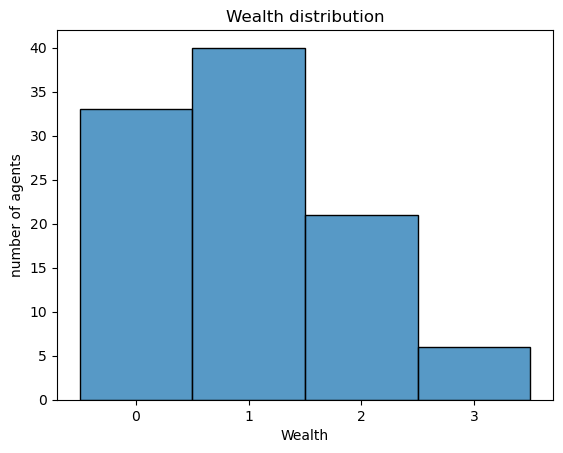

In [26]:
import matplotlib.ticker as ticker

agent_wealth = [a.wealth for a in model.agents]
# Create a histogram with seaborn
g = sns.histplot(agent_wealth, discrete=True)
g.set(
    title="Wealth distribution", xlabel="Wealth", ylabel="number of agents"
);  # The semicolon is just to avoid printing the object representation
g.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
g.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

## Adding Space
Display agents on a 2D grid.  
Use `CellAgent` subclass to handle interaction on grid.  
During each step, each agent will randomly move to one of its moore neighborhood and exchange money with random agent in its moore neighborhood like the first model.  
- `Network` in grid space seems interesting.
- [Mesa-Geo](https://mesa-geo.readthedocs.io/latest/): Extension of Mesa with geographic information.

### Visulization of agents' positions on grid

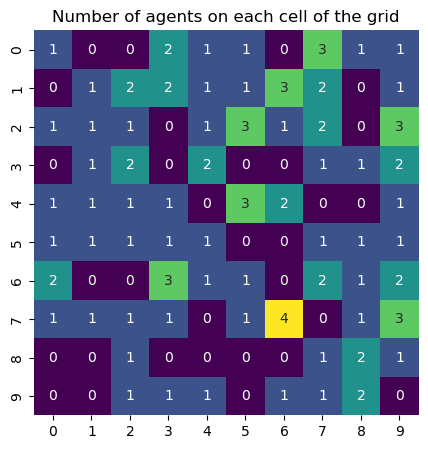

In [20]:
agent_counts = np.zeros((model.grid.width, model.grid.height))

for cell in model.grid.all_cells:
    agent_counts[cell.coordinate] = len(cell.agents)
# Plot using seaborn, with a visual size of 5x5
g = sns.heatmap(agent_counts, cmap="viridis", annot=True, cbar=False, square=True)
g.figure.set_size_inches(5, 5)
g.set(title="Number of agents on each cell of the grid");

## Collecting Data
Add `mesa.Datacollector` in the model definition.
- At the model level, measure the model’s [Gini Coefficient](https://en.wikipedia.org/wiki/Gini_coefficient), a measure of wealth inequality.
- At the agent level, collect every agent’s wealth at every step.

### Calculate/Visulize Gini Coefficient

In [4]:
def compute_gini(model):
    agent_wealths = [agent.wealth for agent in model.agents]
    x = sorted(agent_wealths)
    n = model.num_agents
    B = sum(xi * (n - i) for i, xi in enumerate(x)) / (n * sum(x))
    return 1 + (1 / n) - 2 * B

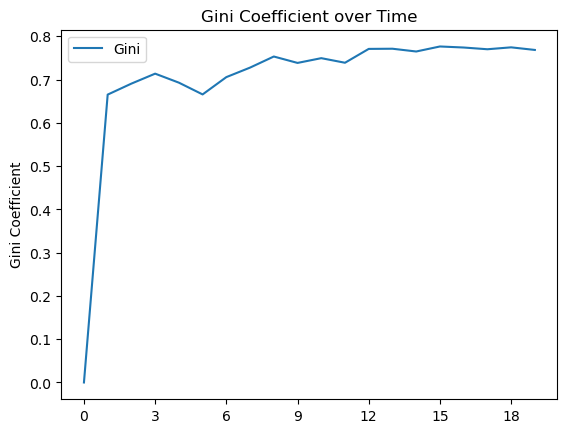

In [53]:
import matplotlib.ticker as ticker
# Extract MoneyModel data in a Pandas dataframe
gini = model.datacollector.get_model_vars_dataframe()

g = sns.lineplot(data=gini)
g.set(title="Gini Coefficient over Time", ylabel="Gini Coefficient");
g.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

### Extract MoneyModel data in a Pandas dataframe step-wise

Data collector stores the data in a dictionary, with the step number as the key, and a dictionary of agent ID and variable value pairs as the value. The data collector then converts this dictionary into a DataFrame, which is why the index is a pair of (model step, agent ID).

In [25]:
# Extract MoneyAgent data in a Pandas dataframe
agent_wealth = model.datacollector.get_agent_vars_dataframe()
agent_wealth.tail()

Wealth Ethnicity
Step AgentID                  
20   96            2      Blue
     97            0     Mixed
     98            4      Blue
     99            0     Mixed
     100           1      Blue

## Agent Set

### Selecting
Use `agents.select` to separate the agents into rich and poor agents. If there are rich agents then they are the only ones who give money.  
Update the `step` and `give_money` method.  

### Group By
Uses `AgentSet.groupby` to group agents by their ethnicity attribute. This will give us a dictionary where the keys are the different ethnicities and the values are an `AgentSet`.  
In this case we will then use the `AgentSet` class and leverage its `shuffle_do` capability to then give money to the target groups.

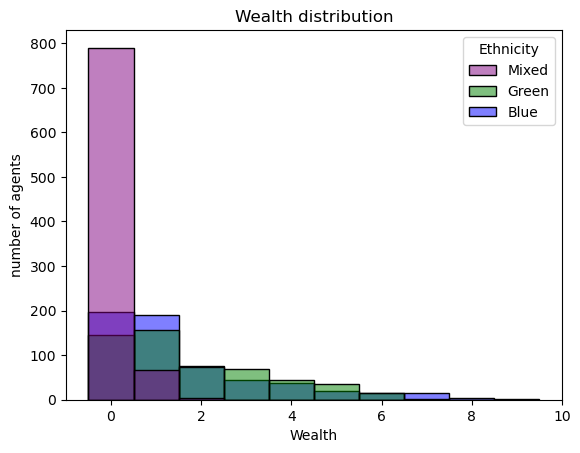

In [8]:
# get the data
data = model.datacollector.get_agent_vars_dataframe()
# assign histogram colors
palette = {"Green": "green", "Blue": "blue", "Mixed": "purple"}
g = sns.histplot(data=data, x="Wealth", hue="Ethnicity", discrete=True, palette=palette)
g.set(title="Wealth distribution", xlabel="Wealth", ylabel="number of agents");

## Dashboard & Interactive Visulization

### Grid & Agent Portayal
Mesa’s grid visualizer works by looping over every cell in a grid, and generating a portrayal for every agent it finds. A portrayal is a dictionary (which can easily be turned into a JSON object) which tells Matplotlib the color and size of the scatterplot markers (each signifying an agent).   
The following code will draw each agent as a blue, filled circle, with a radius size of 50.  
The allowed values for shapes can be found at [matplotlib.markers](https://matplotlib.org/stable/api/markers_api.html).

In [20]:
def agent_portrayal(agent):
    portrayal = {
        "size": 50,
        "color": "tab:red",
        "marker": "^",
    }
    if agent.wealth > 0:
        portrayal["size"] = 50
        portrayal["color"] = "tab:blue"
        portrayal["marker"] = "o"
    return portrayal

### Model Parameter Setter
In addition to the portrayal method, we instantiate the model parameters, some of which are modifiable by user inputs. In this case, the number of agents, N, is specified as a slider of integers.

In [6]:
model_params = {
    "n": {
        "type": "SliderInt",
        "value": 50,
        "label": "Number of agents:",
        "min": 10,
        "max": 100,
        "step": 1,
    },
    "width": 10,
    "height": 10,
}

### Custom Plot Components
Now we add our custom component. In this case we will build a histogram of agent wealth.  
Besides the standard matplotlib code to build a histogram, please notice 3 key features.
- `@solara.component` this is needed for any compoenent you add.
- `update_counter.get()` this is needed so solara updates the dashboard with your agent based model.
- you must initialize a `figure` using this method instead of `plt.figure()`, for thread safety purpose.

In [31]:
@solara.component
def Histogram(model):
    update_counter.get()  # This is required to update the counter
    # Note: you must initialize a figure using this method instead of
    # plt.figure(), for thread safety purpose
    fig = Figure()
    ax = fig.subplots()
    wealth_vals = [agent.wealth for agent in model.agents]
    # Note: you have to use Matplotlib's OOP API instead of plt.hist
    # because plt.hist is not thread-safe.
    ax.hist(wealth_vals, bins=10)
    ax.set_xlabel("Wealth")    
    ax.set_ylabel("Count")   
    solara.FigureMatplotlib(fig)

def GiniPlot(model):
    fig = Figure()
    ax = fig.subplots()
    df = model.datacollector.get_model_vars_dataframe()
    ax.plot(df["Gini"])
    ax.set_xlabel("Step")
    ax.set_ylabel("Gini")
    return solara.FigureMatplotlib(fig)

### Solara Dashboard

In [38]:
# Create initial model instance
money_model = MoneyModel(n=50, width=10, height=10)  # keyword arguments

SpaceGraph = make_space_component(agent_portrayal)
# GiniPlot = make_plot_component("Gini")

page = SolaraViz(
    money_model,
    components=[SpaceGraph, GiniPlot, Histogram],
    model_params=model_params,
    name="Boltzmann Wealth Model",
)
# This is required to render the visualization in the Jupyter notebook
page

Cannot show ipywidgets in text

**Notes**
- ~~Model's `step` function that including `selecting` or `groupby` methods results in zeros in Gini plot.~~ => Dealt with custom Solara component.
- Drawing order matters for the grid.

## Parameter Sweeps
Modelers typically won’t run a model just once, but multiple times, with fixed parameters to find the overall distributions the model generates, and with varying parameters to analyze how these variables drive the model’s outputs and behaviors.  
Mesa provides a `batch_run` function which automates parameter sweeps and allows the model variants to run on multiple processors.

- `model_cls` The model class that is used for the batch run.
  
- `parameters` A dictionary containing all the parameters of the model class and desired values to use for the batch run as key-value pairs. Each value can either be fixed ( e.g. `{"height": 10, "width": 10}`) or an iterable (e.g. `{"n": range(10, 500, 10)}`). batch_run will then generate all possible parameter combinations based on this dictionary and run the model `iterations` times for each combination.

- `number_processes` If not specified, defaults to 1. Set it to `None` to use all the available processors. Note: Multiprocessing does make debugging challenging. If your parameter sweeps are resulting in unexpected errors set `number_processes=1`.

- `iterations` The number of iterations to run each parameter combination for. Optional. If not specified, defaults to 1.

- `data_collection_period` The length of the period (number of steps) after which the model and agent reporters collect data. Optional. If not specified, defaults to -1, i.e. only at the end of each episode.

- `max_steps` The maximum number of time steps after which the model halts. An episode does either end when `self.running` of the model class is set to `False` or when `model.steps == max_steps` is reached. Optional. If not specified, defaults to 1000.

- `display_progress` Display the batch run progress. Optional. If not specified, defaults to `True`.

In [50]:
params = {"seed": 42, "width": 10, "height": 10, "n": [5, 10, 20, 40, 80]}

results = mesa.batch_run(
    MoneyModel,
    parameters=params,
    iterations=25,
    max_steps=100,
    number_processes=1,
    data_collection_period=1,  # Need to collect every step
    display_progress=True,
)

  0%|          | 0/125 [00:00<?, ?it/s]

The total number of runs = different populations * iterations per population.  

As we look varying the parameters to see the impact on model outcomes, it is critical to again point out that users can set the random seed. Due to the often inherent randomness with ABMs the seed becomes crucial for:

- Reproducibility - Being able to replicate the ABM results

- Sensitivity Analysis - Identifying how sensitive/robust your model results are to random fluctuations

Treating the seed as an additional parameter and running numerous scenarios allows us to see the impact of randomness on this model.

### Batch Run Analysis and Visualization

In [51]:
results_df = pd.DataFrame(results)
print(f"The results have {len(results)} rows.")
print(f"The columns of the data frame are {list(results_df.keys())}.")

The results have 387625 rows.
The columns of the data frame are ['RunId', 'iteration', 'Step', 'seed', 'width', 'height', 'n', 'Gini', 'AgentID', 'Wealth', 'Ethnicity'].


First, we want to take a closer look at how the Gini coefficient at the end of each episode changes as we increase the size of the population. For this, we filter our results to only contain the data of one agent (the Gini coefficient will be the same for the entire population at any time) at the 100th step of each episode and then scatter-plot the values for the Gini coefficient over the the number of agents. Notice there are five values for each population size since we set `iterations=5` when calling the batch run.

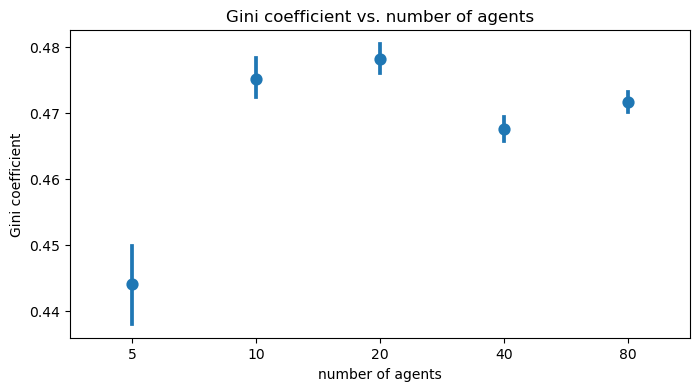

In [53]:
# Filter the results to only contain the data of one agent
# The Gini coefficient will be the same for the entire population at any time
results_filtered = results_df[(results_df.AgentID == 1)]
results_filtered[["iteration", "n", "Gini"]].reset_index(
    drop=True
).head()

# Create a point plot with error bars
g = sns.pointplot(data=results_filtered, x="n", y="Gini", linestyle="None")
g.figure.set_size_inches(8, 4)
g.set(
    xlabel="number of agents",
    ylabel="Gini coefficient",
    title="Gini coefficient vs. number of agents",
);

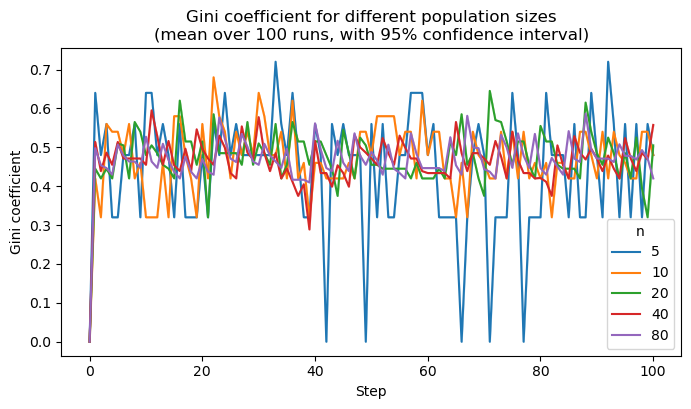

In [56]:
# Create a lineplot with error bars
g = sns.lineplot(
    data=results_df,
    x="Step",
    y="Gini",
    hue="n",
    errorbar=("ci", 95),
    palette="tab10",
)
g.figure.set_size_inches(8, 4)
plot_title = (
    "Gini coefficient for different population sizes\n"
    "(mean over 100 runs, with 95% confidence interval)"
)
g.set(title=plot_title, ylabel="Gini coefficient");

Secondly, we want to display the agent’s wealth at each time step of one specific episode. To do this, we again filter our large data frame, this time with a fixed number of agents and only for a specific iteration of that population. To print the results, we convert the filtered data frame to a string specifying the desired columns to print.

Pandas has built-in functions to convert to a lot of different data formats. For example, to display as a table in a Jupyter, we can use the `to_html()` function which takes the same arguments as `to_string()` (see commented lines).

In [47]:
# First, we filter the results
one_episode_wealth = results_df[(results_df.n == 10) & (results_df.iteration == 2)]
# Then, print the columns of interest of the filtered data frame
"""
print(
    one_episode_wealth.to_string(
        index=False, columns=["Step", "AgentID", "Wealth"], max_rows=10
    )
)
"""
# For a prettier display we can also convert the data frame to html
# Uncomment the two lines below to test in Jupyter
from IPython.display import display, HTML
display(HTML(one_episode_wealth.to_html(index=False, columns=['Step','AgentID', 'Wealth'], max_rows=10)))

Step,AgentID,Wealth
0,NaN,NaN
1,1.0,1.0
1,2.0,1.0
1,3.0,1.0
1,4.0,1.0
...,...,...
100,6.0,0.0
100,7.0,1.0
100,8.0,1.0
100,9.0,2.0


Lastly, we want to take a look at the development of the Gini coefficient over the course of one iteration. Filtering and printing looks almost the same as above, only this time we choose a different episode.

In [48]:
results_one_episode = results_df[
    (results_df.n == 10) & (results_df.iteration == 1) & (results_df.AgentID == 1)
]
# print(results_one_episode.to_string(index=False, columns=["Step", "Gini"], max_rows=10))
display(HTML(results_one_episode.to_html(index=False, columns=["Step", "Gini"], max_rows=10)))

Step,Gini
1,0.42
2,0.54
3,0.48
4,0.34
5,0.32
...,...
96,0.54
97,0.42
98,0.54
99,0.48
